In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/brain_tumor_detection(1)'

# Check if dataset path exists
if os.path.exists(dataset_path):
    print("Root directory contents:", os.listdir(dataset_path))

    for split in ['Training', 'Testing']:
        split_path = os.path.join(dataset_path, split)

        if not os.path.exists(split_path):
            print(f"{split.upper()} folder not found at: {split_path}")
            continue

        print(f"\n{split.upper()} SET:")

        for cls in os.listdir(split_path):
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                image_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                count = len(image_files)
                print(f" - {cls}: {count} images")
else:
    print(f"Dataset path does not exist: {dataset_path}")





Root directory contents: ['Training', 'Testing']

TRAINING SET:
 - notumor: 1595 images
 - glioma: 1321 images
 - meningioma: 1339 images
 - pituitary: 1457 images

TESTING SET:
 - meningioma: 306 images
 - notumor: 405 images
 - glioma: 300 images
 - pituitary: 300 images


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import cv2
from tqdm import tqdm

# ML Models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# DL Models
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, LSTM, TimeDistributed
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Fix random seed for reproducibility
np.random.seed(42)


In [ ]:
# Check if the directories are accessible
train_path = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_path = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

# Print contents of both directories
print("Training directory contents:")
print(os.listdir(train_path))

print("Testing directory contents:")
print(os.listdir(test_path))


Training directory contents:
['notumor', 'glioma', 'meningioma', 'pituitary']
Testing directory contents:
['meningioma', 'notumor', 'glioma', 'pituitary']


In [ ]:
# Check if the directories are correctly formatted
print("Train directory exists:", os.path.isdir(train_path))
print("Test directory exists:", os.path.isdir(test_path))


Train directory exists: True
Test directory exists: True


In [ ]:
from skimage.feature import hog
import cv2

# Function to extract HOG features
def extract_hog_features(image_data, resize_shape=(224, 224)):
    hog_features = []
    for idx, image in enumerate(tqdm(image_data, desc="Extracting HOG features")):
        if image.ndim == 3:  # If it's a 3D array (224, 224, 1), squeeze it to 2D
            image = image.squeeze()  # (224, 224, 1) → (224, 224)

        # Ensure it's a 2D grayscale image
        if image.ndim != 2:
            raise ValueError(f"[{idx}] Image must be 2D grayscale. Got shape: {image.shape}")

        # Resize image if needed (to ensure all images are the same size)
        if image.shape != resize_shape:
            image = cv2.resize(image, resize_shape)

        # Normalize the image to range [0, 1]
        if not np.issubdtype(image.dtype, np.floating):
            image = image.astype('float32') / 255.0

        # Extract HOG features
        feature = hog(image, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm='L2-Hys', feature_vector=True)
        hog_features.append(feature)

    return np.array(hog_features)

# Extract HOG features for both training and testing datasets
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)

# Check shapes after HOG feature extraction
print(f"X_train_hog shape: {X_train_hog.shape}")
print(f"X_test_hog shape: {X_test_hog.shape}")


Extracting HOG features: 100%|██████████| 1143/1143 [00:12<00:00, 88.20it/s]

X_train_hog shape: (4569, 6084)
X_test_hog shape: (1143, 6084)


In [ ]:
X_train_hog = extract_hog_features(X_train_images)
X_test_hog = extract_hog_features(X_test_images)

print(X_train_hog.shape, y_train_encoded.shape)



Extracting HOG features: 100%|██████████| 1311/1311 [00:14<00:00, 88.89it/s]

(5712, 6084) (5712,)


In [ ]:
# ML Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, f1_score, classification_report

# XGBoost
import xgboost as xgb

# Deep Learning Libraries (Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, LSTM
from tensorflow.keras.utils import to_categorical
import seaborn as sns
from sklearn.model_selection import train_test_split


In [ ]:
# Load data from folders
X_train_images, y_train = load_images_from_directory(train_path)
X_test_images, y_test = load_images_from_directory(test_path)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print(X_train_images.shape, y_train_encoded.shape)
print(X_test_images.shape, y_test_encoded.shape)


Loading images from: /content/drive/MyDrive/brain_tumor_detection(1)/Training


Loading pituitary: 100%|██████████| 1457/1457 [00:25<00:00, 56.37it/s] 


Loaded 5712 images.
Loading images from: /content/drive/MyDrive/brain_tumor_detection(1)/Testing


Loading pituitary: 100%|██████████| 300/300 [00:03<00:00, 97.56it/s] 


Loaded 1311 images.
(5712, 224, 224) (5712,)
(1311, 224, 224) (1311,)



Training SVM...
SVM Accuracy: 0.96
Confusion Matrix for SVM:
 [[271  27   0   2]
 [ 10 285   6   5]
 [  0   0 405   0]
 [  1   2   0 297]]
Classification Report for SVM:
               precision    recall  f1-score   support

           0       0.96      0.90      0.93       300
           1       0.91      0.93      0.92       306
           2       0.99      1.00      0.99       405
           3       0.98      0.99      0.98       300

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311


Training Logistic Regression...
Logistic Regression Accuracy: 0.95
Confusion Matrix for Logistic Regression:
 [[266  31   0   3]
 [ 16 274   9   7]
 [  0   0 405   0]
 [  2   4   0 294]]
Classification Report for Logistic Regression:
               precision    recall  f1-score   support

           0       0.94      0.89      0.91       300
           1       0.89      0.90      0.89     

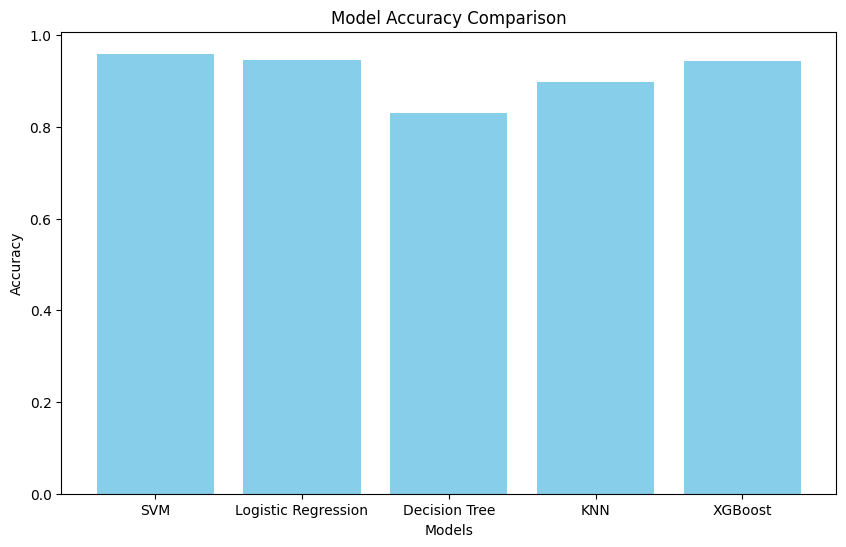

In [ ]:
# Define ML models
models = {
    "SVM": SVC(kernel='linear'),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": xgb.XGBClassifier()
}

# Dictionary to store the results
results = {}

# Train and evaluate models
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train the model
    model.fit(X_train_hog, y_train_encoded)

    # Predict on the test set
    y_pred = model.predict(X_test_hog)

    # Calculate accuracy
    accuracy = accuracy_score(y_test_encoded, y_pred)

    # Store results
    results[name] = accuracy

    # Print Evaluation Metrics
    print(f"{name} Accuracy: {accuracy:.2f}")
    print(f"Confusion Matrix for {name}:\n", confusion_matrix(y_test_encoded, y_pred))
    print(f"Classification Report for {name}:\n", classification_report(y_test_encoded, y_pred))

# Plot Model Accuracy Comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


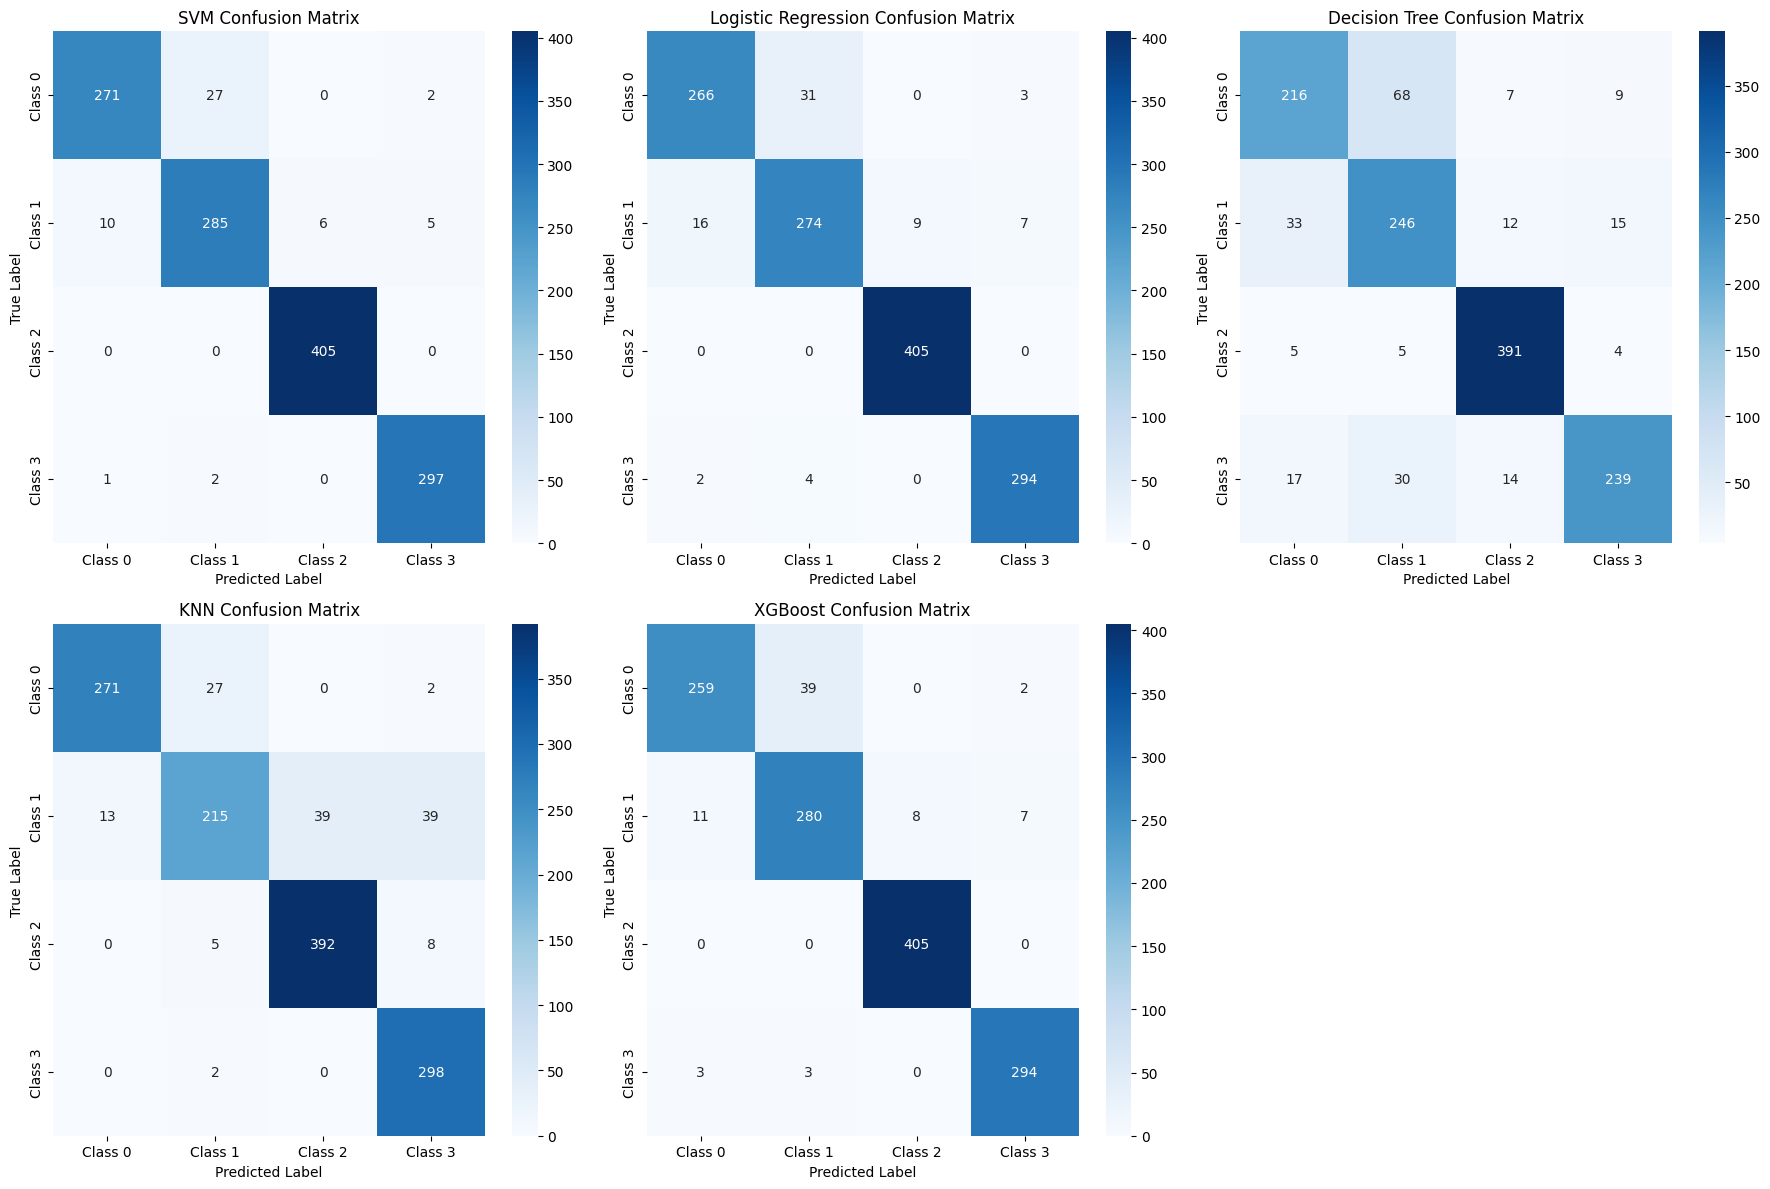

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define your confusion matrices
conf_matrices = {
    "SVM": np.array([[271, 27, 0, 2],
                     [10, 285, 6, 5],
                     [0, 0, 405, 0],
                     [1, 2, 0, 297]]),

    "Logistic Regression": np.array([[266, 31, 0, 3],
                                     [16, 274, 9, 7],
                                     [0, 0, 405, 0],
                                     [2, 4, 0, 294]]),

    "Decision Tree": np.array([[216, 68, 7, 9],
                               [33, 246, 12, 15],
                               [5, 5, 391, 4],
                               [17, 30, 14, 239]]),

    "KNN": np.array([[271, 27, 0, 2],
                     [13, 215, 39, 39],
                     [0, 5, 392, 8],
                     [0, 2, 0, 298]]),

    "XGBoost": np.array([[259, 39, 0, 2],
                         [11, 280, 8, 7],
                         [0, 0, 405, 0],
                         [3, 3, 0, 294]])
}

class_names = ["Class 0", "Class 1", "Class 2", "Class 3"]

# Plot all confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (model_name, cm) in enumerate(conf_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    axes[i].set_title(f'{model_name} Confusion Matrix')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

# Remove extra subplot if any (6 plots in 2x3 grid, but you only have 5)
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# SVM classification report (manually entered from your output)
svm_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.96, 0.91, 0.99, 0.98],
    'recall':    [0.90, 0.93, 1.00, 0.99],
    'f1-score':  [0.93, 0.92, 0.99, 0.98],
}

# Do the same for the other models
log_reg_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.94, 0.89, 0.98, 0.97],
    'recall':    [0.89, 0.90, 1.00, 0.98],
    'f1-score':  [0.91, 0.89, 0.99, 0.97],
}

dt_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.81, 0.70, 0.93, 0.87],
    'recall':    [0.72, 0.79, 0.96, 0.81],
    'f1-score':  [0.76, 0.74, 0.94, 0.84],
}

knn_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.95, 0.86, 0.91, 0.86],
    'recall':    [0.90, 0.70, 0.97, 0.99],
    'f1-score':  [0.93, 0.77, 0.94, 0.92],
}

xgb_data = {
    'Class': ['0', '1', '2', '3'],
    'precision': [0.95, 0.87, 0.98, 0.97],
    'recall':    [0.86, 0.92, 1.00, 0.98],
    'f1-score':  [0.90, 0.89, 0.99, 0.98],
}


In [ ]:
def plot_classification_report(data, title):
    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars='Class', var_name='Metric', value_name='Score')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_melted, x='Class', y='Score', hue='Metric')
    plt.title(title)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.show()


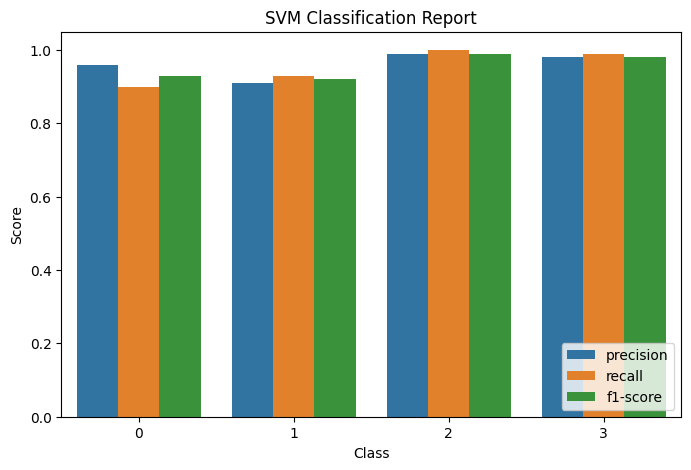

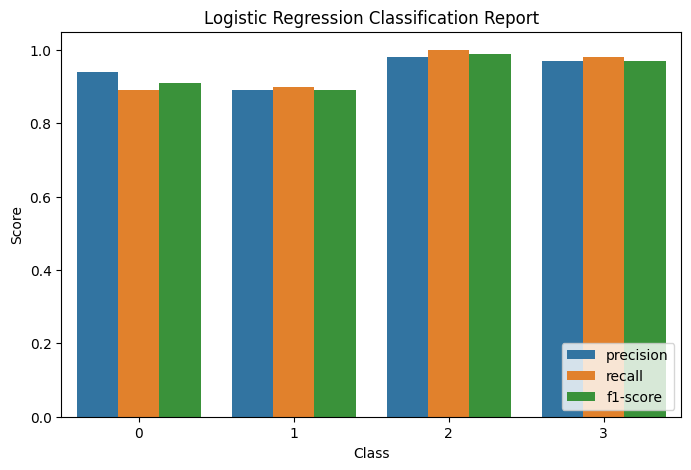

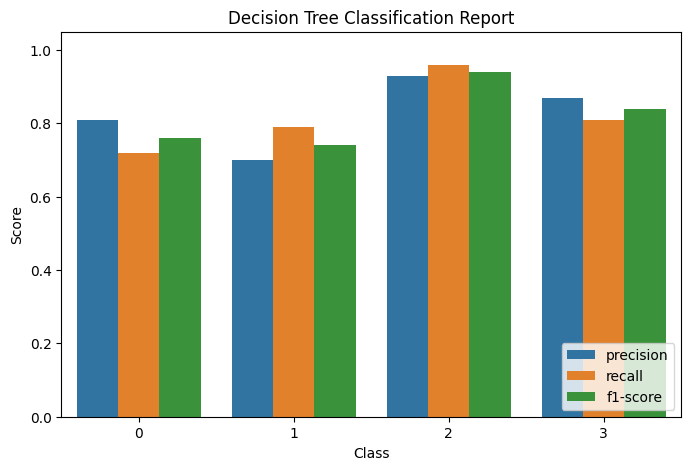

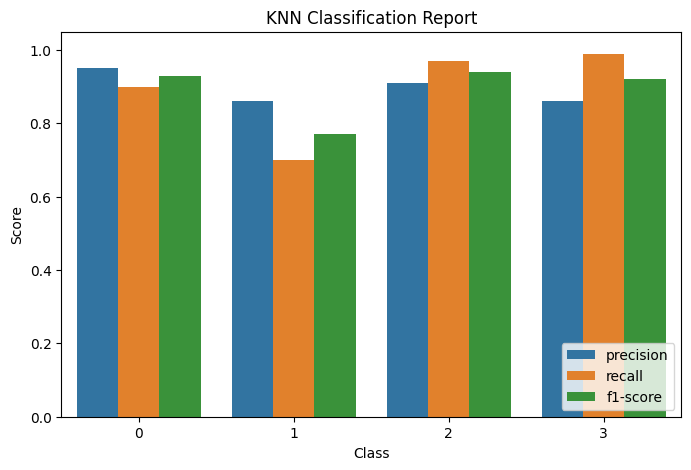

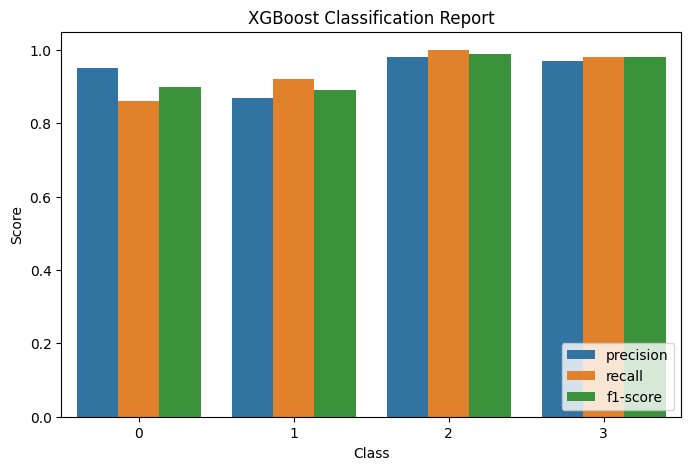

In [ ]:
plot_classification_report(svm_data, 'SVM Classification Report')
plot_classification_report(log_reg_data, 'Logistic Regression Classification Report')
plot_classification_report(dt_data, 'Decision Tree Classification Report')
plot_classification_report(knn_data, 'KNN Classification Report')
plot_classification_report(xgb_data, 'XGBoost Classification Report')


In [ ]:
import pandas as pd

# Manually created classification report for each model
all_data = []

models = {
    'SVM': [[0.96, 0.90, 0.93], [0.91, 0.93, 0.92], [0.99, 1.00, 0.99], [0.98, 0.99, 0.98]],
    'LogReg': [[0.94, 0.89, 0.91], [0.89, 0.90, 0.89], [0.98, 1.00, 0.99], [0.97, 0.98, 0.97]],
    'DecisionTree': [[0.81, 0.72, 0.76], [0.70, 0.79, 0.74], [0.93, 0.96, 0.94], [0.87, 0.81, 0.84]],
    'KNN': [[0.95, 0.90, 0.93], [0.86, 0.70, 0.77], [0.91, 0.97, 0.94], [0.86, 0.99, 0.92]],
    'XGBoost': [[0.95, 0.86, 0.90], [0.87, 0.92, 0.89], [0.98, 1.00, 0.99], [0.97, 0.98, 0.98]]
}

for model_name, class_scores in models.items():
    for i, scores in enumerate(class_scores):
        all_data.append({
            'Model': model_name,
            'Class': f'Class {i}',
            'Precision': scores[0],
            'Recall': scores[1],
            'F1-Score': scores[2]
        })

df = pd.DataFrame(all_data)


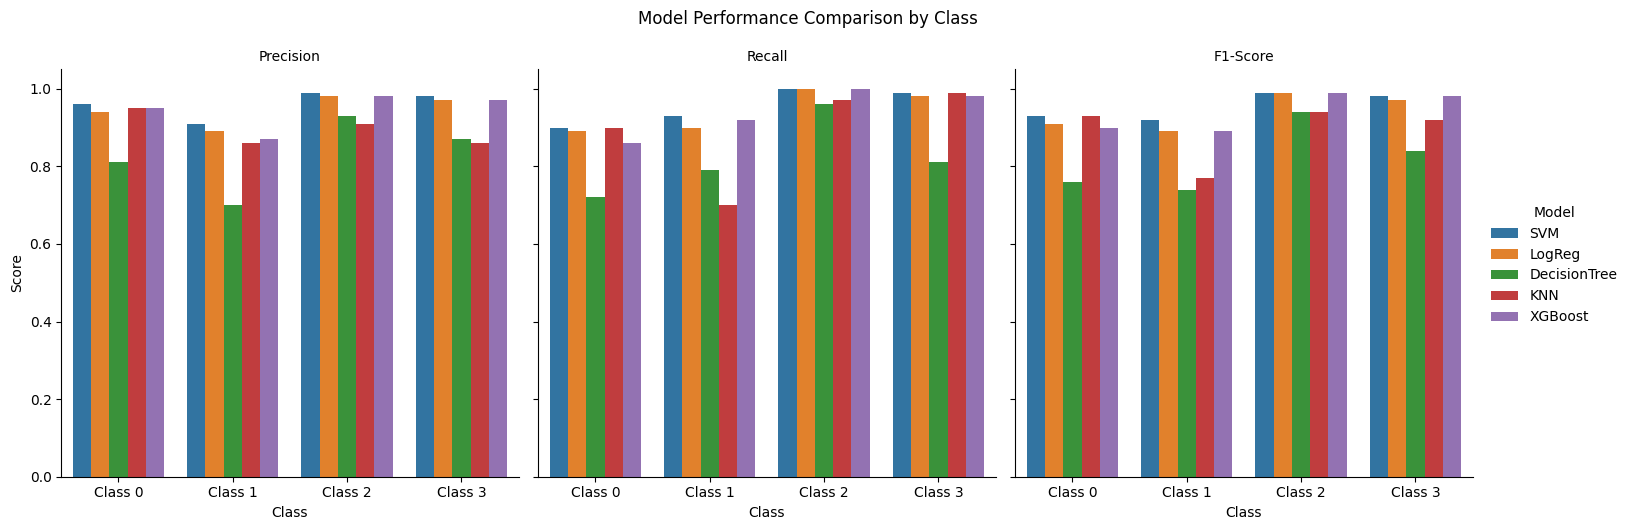

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the DataFrame for easier plotting
df_melted = df.melt(id_vars=['Model', 'Class'], var_name='Metric', value_name='Score')

# Plot with FacetGrid
g = sns.catplot(
    data=df_melted,
    kind='bar',
    x='Class',
    y='Score',
    hue='Model',
    col='Metric',
    height=5,
    aspect=1
)

g.set_titles('{col_name}')
g.set(ylim=(0, 1.05))
g.fig.suptitle('Model Performance Comparison by Class', y=1.05)
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, LSTM, SimpleRNN, Embedding, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
train_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Training'
test_dir = '/content/drive/MyDrive/brain_tumor_detection(1)/Testing'

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Classes detected in training set:", train_generator.class_indices)
print("Classes detected in test set:", test_generator.class_indices)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Classes detected in training set: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Classes detected in test set: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
